In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from PIL import Image
import albumentations as A
import cv2
from matplotlib import pyplot as plt

In [3]:
KEYPOINT_COLOR = (0, 255, 0) # Green

def vis_keypoints(im, keypoints, color=KEYPOINT_COLOR, diameter=5):
    im = im.copy()

    for (x, y) in keypoints:
        cv2.circle(im, (int(x), int(y)), diameter, color, -1)

    # plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.imshow(im)

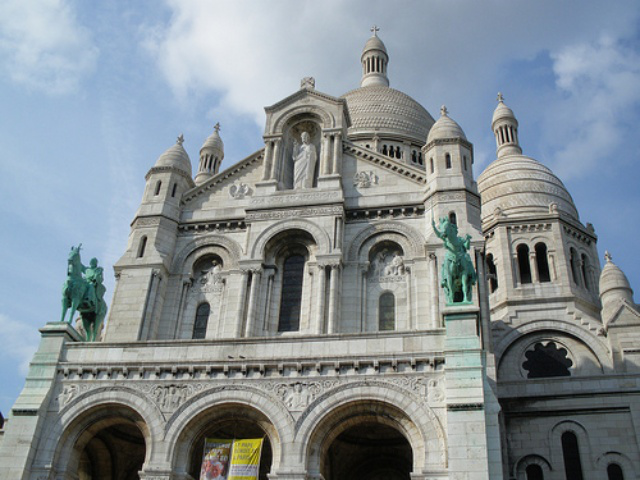

In [4]:
image = Image.open('../data/sacre_coeur_A.jpg')
image

Image Size : (640, 480)
image_np Shape : (480, 640, 3)


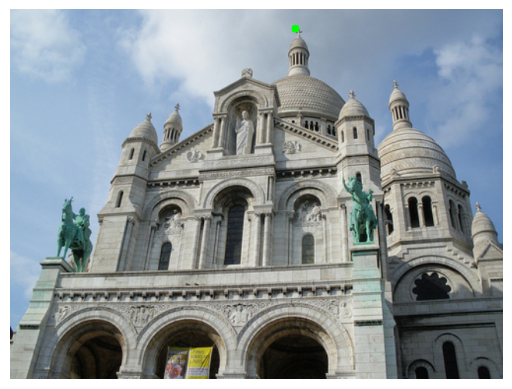

In [5]:
keypoint = (x, y) = (370, 25) # (x, y) horizontal, vertical

width, height = image.size
print(f'Image Size : {width, height}')

patch_size = 128
patch_size_half = patch_size // 2

image_np = np.array(image)
print(f'image_np Shape : {image_np.shape}')

keypoints = [keypoint]
vis_keypoints(image_np, keypoints)

306 434 0 128
[[64.0, 25.0]]


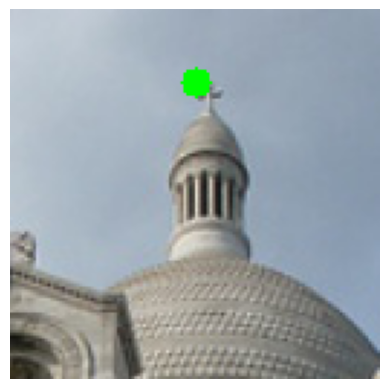

In [6]:
left, right = x - patch_size_half, x + patch_size_half
upper, lower = y - patch_size_half, y + patch_size_half

if left < 0:
    right += -left
    left = 0
elif right > width:
    left -= right - width
    right = width

if upper < 0:
    lower += -upper
    upper = 0
elif lower > height:
    upper -= lower - height
    lower = height
    
print(left, right, upper, lower)
    
transform = A.Compose(
    transforms=[
        A.Crop(
            x_min=left, y_min=upper, 
            x_max=right, y_max=lower
        ),
    ], 
    keypoint_params=A.KeypointParams(format='xy')
)

transformed = transform(image=image_np, keypoints=keypoints)

transformed_image = transformed['image']
transformed_keypoints = transformed['keypoints']
print(transformed_keypoints)

vis_keypoints(transformed_image, transformed_keypoints)

[[295.54534912109375, 73.16658020019531]]


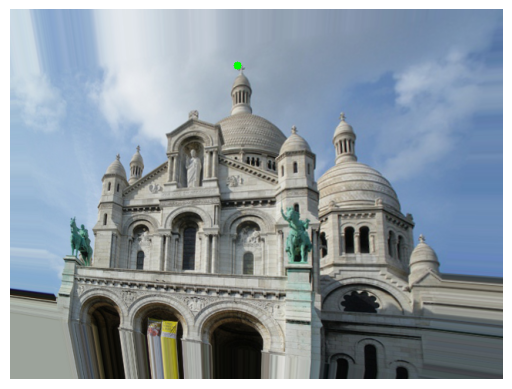

In [18]:
transform = A.Compose(
    transforms=[
        A.Perspective(keep_size=True, fit_output=True, p=1, 
                      scale=1.5,
                      pad_mode=cv2.BORDER_REPLICATE
                      )
    ], 
    keypoint_params=A.KeypointParams(format='xy')
)

transformed = transform(image=image_np, keypoints=keypoints)

transformed_image = transformed['image']
transformed_keypoints = transformed['keypoints']
print(transformed_keypoints)

vis_keypoints(transformed_image, transformed_keypoints)

In [8]:
transformed_keypoints

[[89.76179504394531, 33.678199768066406]]